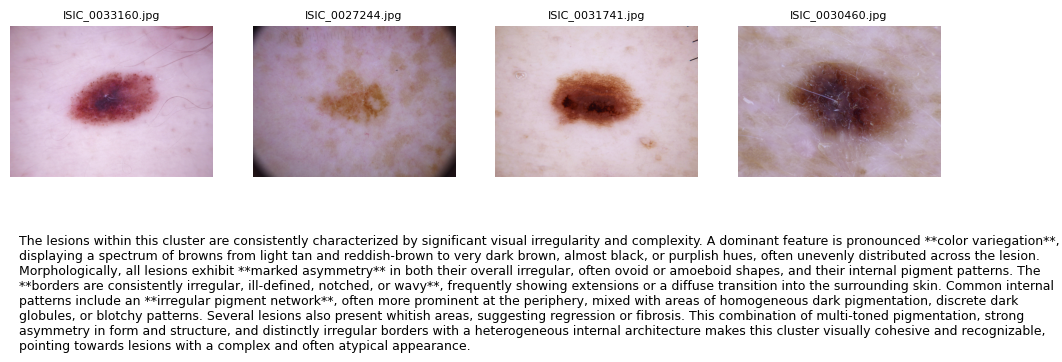

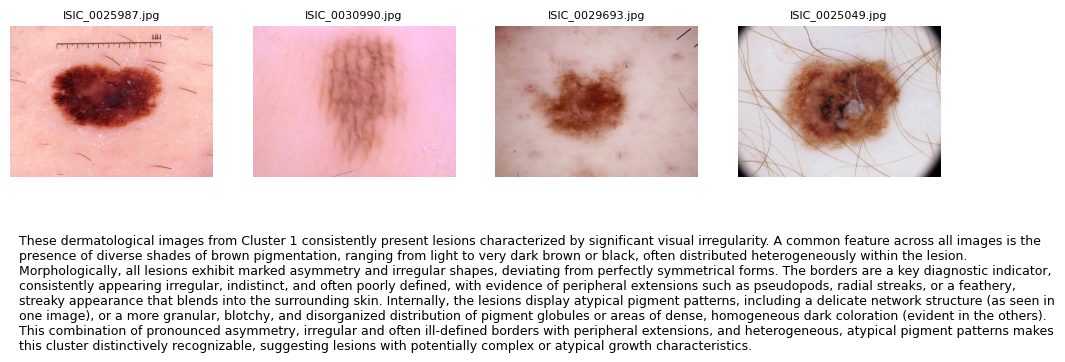

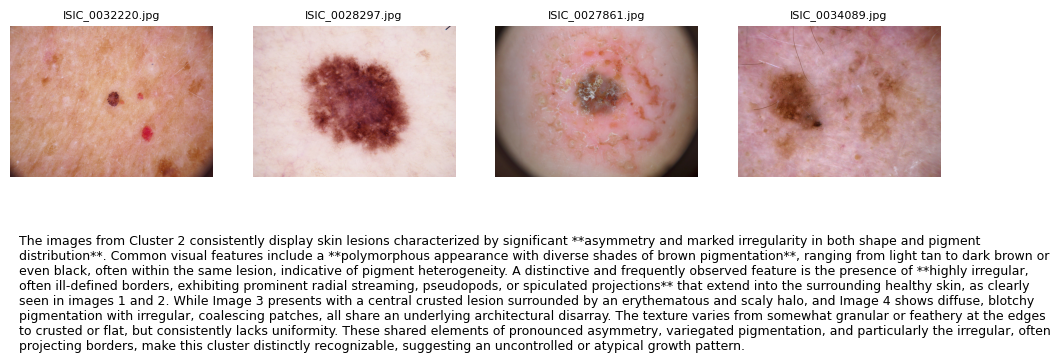

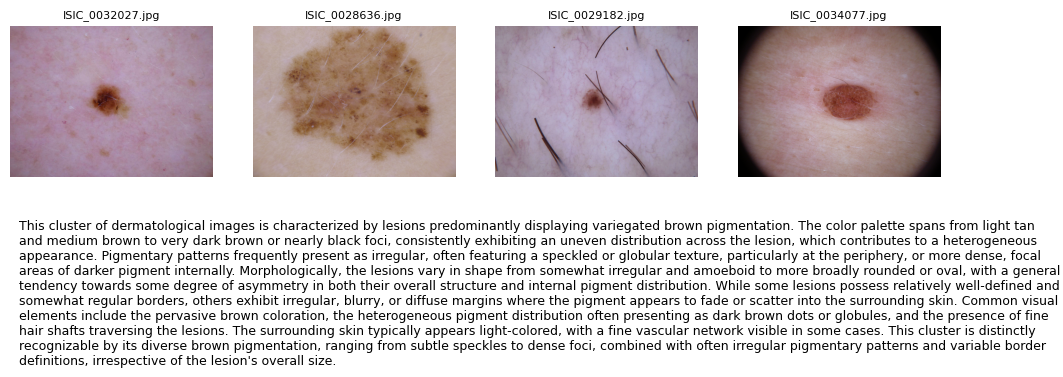

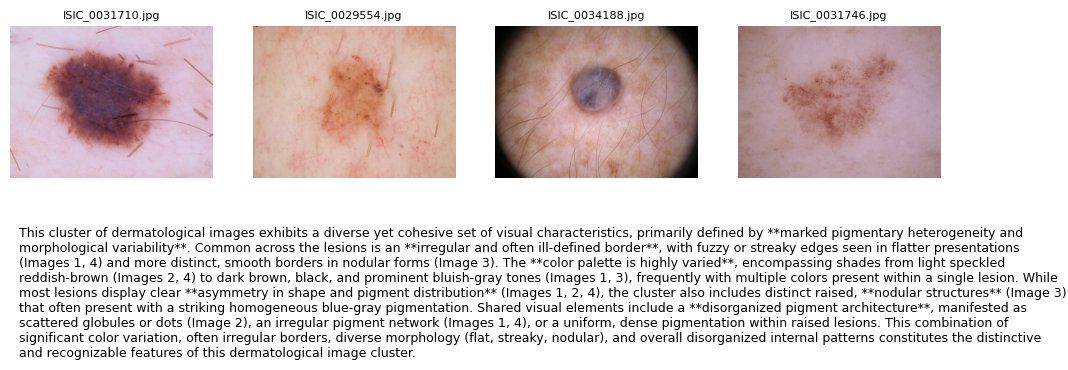

**Concepts (30):**


**Class-specific concepts:**

**mel:**

**nv:**

In [ ]:
# Interactive Concept Browser for HAM10000 (Gemini)
# Single cell UI: choose k, n, c; visualize representatives and paragraphs; list concepts.

import json, os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import gridspec
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown, HTML

# Root locations (relative to this notebook's folder)
NB_DIR = Path.cwd()  # assumes notebook opened from repo root or this folder; we also try __file__ fallback
THIS_DIR = Path('.')
CLUSTERS_DIR = THIS_DIR / 'clusters'
CONCEPTS_DIR = THIS_DIR / 'concepts'
DATASETS_DIR = Path('datasets')

# Fixed defaults per request; adjust if you want to browse other datasets/extractors
DATASET = 'ham10000'
EXTRACTOR = 'gemini'  # 'gemini' or 'qwen'

# Dropdowns for k, n, c (supported values from pipeline summary)
k_dd = widgets.Dropdown(options=[1,3,5,10], value=3, description='k (clusters)')
n_dd = widgets.Dropdown(options=[1,2,4], value=4, description='n (reps)')
c_dd = widgets.Dropdown(options=[1,3,5,10,30,50,100,200], value=30, description='c (concepts)')

out = widgets.Output()

def _safe_read_json(path: Path):
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except Exception:
        return None

def _extract_paths_from_dict(d):
    # Helper to pull paths from known keys
    for key in ['representative_images','representatives','samples','images','paths']:
        v = d.get(key)
        if isinstance(v, list):
            paths = []
            for r in v:
                if isinstance(r, str):
                    paths.append(r)
                elif isinstance(r, dict):
                    for kk in ['image_path','img_path','path','image','img','filepath']:
                        if kk in r:
                            paths.append(r[kk])
                            break
            return paths
    return []

def _normalize_representation(rep_json):
    """
    Attempt to normalize representative structure into: list of clusters,
    where each cluster is a dict { 'cluster_id': int, 'paths': [str,...] }.
    """
    clusters = []
    if rep_json is None:
        return clusters
    # Case 1: dict with 'clusters'
    if isinstance(rep_json, dict) and 'clusters' in rep_json:
        for i, cl in enumerate(rep_json['clusters']):
            cid = cl.get('cluster_id', i)
            paths = _extract_paths_from_dict(cl)
            clusters.append({'cluster_id': cid, 'paths': paths})
        return clusters
    # Case 2: dict mapping cluster keys to lists/dicts
    if isinstance(rep_json, dict):
        for i, (k, v) in enumerate(sorted(rep_json.items(), key=lambda x: str(x[0]))):
            paths = []
            if isinstance(v, list):
                for r in v:
                    if isinstance(r, str):
                        paths.append(r)
                    elif isinstance(r, dict):
                        for key in ['image_path','img_path','path','image','img','filepath']:
                            if key in r:
                                paths.append(r[key])
                                break
            elif isinstance(v, dict):
                paths = _extract_paths_from_dict(v)
            clusters.append({'cluster_id': int(k) if str(k).isdigit() else i, 'paths': paths})
        return clusters
    # Case 3: list of clusters or items
    if isinstance(rep_json, list):
        for i, item in enumerate(rep_json):
            # If item is dict with cluster_id and representative_images
            if isinstance(item, dict):
                cid = item.get('cluster_id', i)
                paths = _extract_paths_from_dict(item)
                if not paths:
                    reps = item.get('representatives') or item.get('images') or item.get('samples') or []
                    if isinstance(reps, list):
                        for r in reps:
                            if isinstance(r, str):
                                paths.append(r)
                            elif isinstance(r, dict):
                                for key in ['image_path','img_path','path','image','img','filepath']:
                                    if key in r:
                                        paths.append(r[key])
                                        break
                clusters.append({'cluster_id': cid, 'paths': paths})
            else:
                # Fallback if item is a list of paths
                paths = []
                if isinstance(item, list):
                    for r in item:
                        if isinstance(r, str):
                            paths.append(r)
                clusters.append({'cluster_id': i, 'paths': paths})
        return clusters
    return clusters

def _normalize_paragraphs(par_json):
    """
    Normalize paragraphs into dict: cluster_id -> paragraph (str).
    Supports: list of dicts with cluster_id/paragraph, list[str], dict[str|int]->str, or dict with 'paragraphs'.
    """
    out = {}
    if par_json is None:
        return out
    if isinstance(par_json, dict) and 'paragraphs' in par_json:
        par_json = par_json['paragraphs']
    if isinstance(par_json, list):
        for i, p in enumerate(par_json):
            if isinstance(p, dict) and ('paragraph' in p or 'text' in p):
                cid = p.get('cluster_id', i)
                out[cid] = p.get('paragraph') or p.get('text') or ''
            elif isinstance(p, str):
                out[i] = p
    elif isinstance(par_json, dict):
        for k, v in par_json.items():
            if isinstance(v, str): out[int(k) if str(k).isdigit() else k] = v
            elif isinstance(v, dict): out[int(k) if str(k).isdigit() else k] = v.get('paragraph') or v.get('text') or ''
    return out

def _normalize_concepts(con_json):
    """Return (all_concepts, class_concepts_map) from typical shapes."""
    all_concepts = []
    class_map = {}
    if con_json is None:
        return all_concepts, class_map
    if isinstance(con_json, dict):
        if 'all' in con_json and isinstance(con_json['all'], list):
            all_concepts = [str(x) for x in con_json['all']]
        elif 'concepts' in con_json and isinstance(con_json['concepts'], list):
            all_concepts = [str(x) for x in con_json['concepts']]
        elif 'concept_list' in con_json and isinstance(con_json['concept_list'], list):
            all_concepts = [str(x) for x in con_json['concept_list']]
        # class concepts if present
        if 'class_concepts' in con_json and isinstance(con_json['class_concepts'], dict):
            for cls, arr in con_json['class_concepts'].items():
                if isinstance(arr, list):
                    class_map[str(cls)] = [str(x) for x in arr]
        # fallback: any list at top-level if 'all' not present
        if not all_concepts:
            for k, v in con_json.items():
                if isinstance(v, list):
                    all_concepts = [str(x) for x in v]
                    break
    elif isinstance(con_json, list):
        all_concepts = [str(x) for x in con_json]
    return all_concepts, class_map

def _resolve_image_path(p):
    """Best effort to resolve an image path p."""
    if not p:
        return None
    p = Path(p)
    if p.exists():
        return p
    # Try relative to THIS_DIR
    if (THIS_DIR / p).exists():
        return THIS_DIR / p
    # Try dataset images dir
    img_dir = DATASETS_DIR / DATASET / 'images'
    if (img_dir / p).exists():
        return img_dir / p
    if (img_dir / p.name).exists():
        return img_dir / p.name
    return None

def render(k:int, n:int, c:int):
    clear_output(wait=True)
    display(widgets.HBox([k_dd, n_dd, c_dd]))
    # File paths
    rep_path = CLUSTERS_DIR / DATASET / f'representative_{k}_{n}.json'
    par_path = CLUSTERS_DIR / EXTRACTOR / DATASET / f'paragraph_{k}_{n}.json'
    con_path = CONCEPTS_DIR / EXTRACTOR / DATASET / f'concept_all_{k}_{n}_{c}.json'

    rep_json = _safe_read_json(rep_path)
    par_json = _safe_read_json(par_path)
    con_json = _safe_read_json(con_path)

    reps = _normalize_representation(rep_json)
    pars = _normalize_paragraphs(par_json)
    concepts, class_map = _normalize_concepts(con_json)

    if not reps:
        display(Markdown(f"**No representatives found at:** `{rep_path}`"))
        return

    # Limit to k clusters (in order)
    reps = reps[:k]

    for i, cl in enumerate(reps):
        paths = cl.get('paths', [])[:n]
        # Prepare figure: n columns for images, 1 row for images + 1 row (spanning) for paragraph
        fig = plt.figure(figsize=(3.0*n, 4.2))  # slightly taller for padding
        gs = gridspec.GridSpec(2, n, height_ratios=[4, 1])
        gs.update(hspace=0.5)  # add vertical padding between image row and text row
        # Image row
        for j in range(n):
            ax = fig.add_subplot(gs[0, j])
            ax.axis('off')
            img_path = _resolve_image_path(paths[j]) if j < len(paths) else None
            title = Path(paths[j]).name if j < len(paths) else 'N/A'
            if img_path and img_path.exists():
                try:
                    img = Image.open(img_path).convert('RGB')
                    ax.imshow(img)
                    ax.set_title(title, fontsize=8)
                except Exception:
                    ax.text(0.5, 0.5, f"Load error: {title}", ha='center', va='center', fontsize=8)
            else:
                ax.text(0.5, 0.5, f"Missing image: {title}", ha='center', va='center', fontsize=8)
        # Paragraph row (single axis spanning all columns)
        ax_text = fig.add_subplot(gs[1, :])
        ax_text.axis('off')
        cid = cl.get('cluster_id', i)
        para = pars.get(cid) or pars.get(str(cid)) or ''
        if not para:
            para = f'No paragraph found for cluster {cid} in {par_path.name}'
        ax_text.text(0.01, 0.5, para, fontsize=9, va='center', ha='left', wrap=True)
        plt.subplots_adjust(hspace=0.6, bottom=0.12)  # ensure extra space between rows and at bottom
        plt.show()

    # Concepts list at the end in 3 columns
    if concepts:
        display(Markdown(f'**Concepts ({len(concepts)}):**'))
        # Split into 3 columns
        num_cols = 3
        items_per_col = (len(concepts) + num_cols - 1) // num_cols
        
        html = '<div style="display: flex; gap: 20px;">'
        for col in range(num_cols):
            start_idx = col * items_per_col
            end_idx = min(start_idx + items_per_col, len(concepts))
            html += '<div style="flex: 1;">'
            for idx in range(start_idx, end_idx):
                html += f'{idx + 1}. {concepts[idx]}<br>'
            html += '</div>'
        html += '</div>'
        display(HTML(html))
    else:
        display(Markdown(f'**No concepts found at:** `{con_path}`'))

    # Class-specific concepts if available in 3 columns
    if class_map:
        # Compute uniqueness across classes
        freq = {}
        for cls, items in class_map.items():
            for it in items:
                freq[it] = freq.get(it, 0) + 1
        
        display(Markdown('\n**Class-specific concepts:**'))
        for cls in sorted(class_map.keys()):
            items = class_map[cls]
            display(Markdown(f'**{cls}:**'))
            
            # Split into 3 columns
            num_cols = 3
            items_per_col = (len(items) + num_cols - 1) // num_cols
            
            html = '<div style="display: flex; gap: 20px; margin-left: 20px;">'
            for col in range(num_cols):
                start_idx = col * items_per_col
                end_idx = min(start_idx + items_per_col, len(items))
                html += '<div style="flex: 1;">'
                for idx in range(start_idx, end_idx):
                    it = items[idx]
                    if freq.get(it, 0) == 1:
                        html += f'<strong>{it}</strong><br>'
                    else:
                        html += f'{it}<br>'
                html += '</div>'
            html += '</div>'
            display(HTML(html))

# Wire up interactions
ui = widgets.HBox([k_dd, n_dd, c_dd])
display(ui)

def on_change(*args):
    render(k_dd.value, n_dd.value, c_dd.value)

k_dd.observe(on_change, names='value')
n_dd.observe(on_change, names='value')
c_dd.observe(on_change, names='value')

# Initial render
render(k_dd.value, n_dd.value, c_dd.value)
